# Qual abordagem ficou melhor?

Entre 26 e 28/08/2026 testamos oito caminhos para melhorar o detector do TC-330.03A.
Este notebook põe todos na mesma régua e responde qual venceu.

**O critério, declarado antes de olhar os números.** Uma abordagem só entra na disputa se
respeitar o **teto de 1 falso positivo por mês**. Entre as que respeitam, a ordem é:

1. **falhas antecipadas** — é para isso que o detector existe;
2. **horas por mês em alarme falso** — é o que a operação sente; 0,94 episódio/mês soa
   pequeno, 22 h/mês de alarme não;
3. **antecedência média** — quanto tempo o alerta dá para agir;
4. **robustez** — quantas configurações distintas entregam aquele resultado. Uma abordagem
   que só funciona num ponto do grid é frágil a mudança de regime do equipamento.

**As oito abordagens**, em três grupos:

| grupo | abordagens |
|---|---|
| operabilidade e limpeza | referência · porteiro de exaustão (T5) · descarte de partida de 24 h · **silêncio pós-partida de 24 h** |
| engenharia de features | resíduo de carga · vibração como 5º sinal |
| arquitetura | PCA · autoencoder |

Os dois primeiros grupos são recalculados aqui. O terceiro vem das varreduras de
10.368 configurações rodadas no ClearML, porque o autoencoder no seu melhor ponto exige a
grade de 30 s — cada ajuste custa 61 s e são 60 por varredura.

In [1]:
import sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src")); sys.path.insert(0, str(RAIZ / "scripts"))
warnings.filterwarnings("ignore")

from cabiunas_pdm import viz
from cabiunas_pdm.replay import DetectionReplay, CachedBundle, load_automl

automl = load_automl(); viz.usar_estilo()
pd.set_option("display.width", 200)

CONFIG = dict(model="pca", grid="2min", exclude_days=0, exclude_alarm_h=1.0,
              ewma="2h", threshold=99.9, sustain="30min", confirm=2, min_alert="0min")
POLITICA = automl.BaselinePolicy(window_hours=3000)
TETO_FP = 1.0
CACHES = RAIZ / "data/interim/comparacao"; CACHES.mkdir(parents=True, exist_ok=True)
resultados = []      # cada abordagem vira uma linha aqui

## 1. Operabilidade e limpeza

Quatro mundos, a mesma configuração de detector em todos. O que muda é **quais amostras
existem** para o modelo e para o alerta.

Atenção a um detalhe que já nos custou um dia de varredura: o cache de scores é indexado
por modelo, grade, baseline e exclusões — **não** pelo porteiro nem pelo descarte de
partida. Cada variante precisa do seu próprio diretório de cache, senão reaproveita
silenciosamente os scores do mundo errado.

In [2]:
def rodar(nome, gate="off", startup="2h", silencio="0h", descricao=""):
    '''Roda a configuração de produção num mundo de operabilidade específico.'''
    automl.EXHAUST_GATE, automl.EXHAUST_MIN_H = gate, 1.0
    automl.STARTUP_EXCLUDE, automl.POST_START_SILENCE = startup, silencio
    bundle = CachedBundle().build()
    bundle._grids.clear(); bundle._trips = None
    cache = CACHES / f"{nome}"; cache.mkdir(exist_ok=True)
    t0 = time.time()
    r = DetectionReplay(bundle=bundle, cache_dir=cache).run(baseline=POLITICA, **CONFIG)
    m = r.metrics
    resultados.append(dict(
        abordagem=nome, grupo="operabilidade", descricao=descricao,
        eventos=m["eventos_detectados"], lead_h=m["lead_medio_h"],
        fp_mes=m["fp_por_mes"], fp_liquido=m["fp_por_mes_liquido"],
        h_alarme_falso=m["fp_horas_por_mes"], episodios=m["episodios_totais"],
        dias_avaliados=m["dias_avaliados"], fonte="replay local", segundos=round(time.time()-t0)))
    return r

MUNDOS = [
    ("referência",      dict(descricao="o detector como está em produção")),
    ("silêncio 24 h",   dict(silencio="24h", descricao="alerta suprimido 24 h após cada partida")),
    ("porteiro T5",     dict(gate="stable",  descricao="T5 >= 500 °C limpando treino e pontuação")),
    ("descarte 24 h",   dict(startup="24h",  descricao="descarte de partida ampliado no baseline")),
]
rodadas = {}
for nome, kw in MUNDOS:
    descricao = kw.pop("descricao")
    rodadas[nome] = rodar(nome, descricao=descricao, **kw)
automl.EXHAUST_GATE, automl.STARTUP_EXCLUDE, automl.POST_START_SILENCE = "off", "2h", "0h"

pd.DataFrame(resultados).set_index("abordagem")[
    ["eventos","lead_h","fp_mes","h_alarme_falso","episodios","dias_avaliados","segundos"]]

[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


...

[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[scores] cache replay_parts_4sinais_pca_2min_3000h_0_1.0_1d30ff1f.pkl


[replay] pca|2min|b3000h|excl0d|alm1.0h|ewma2h|q99.9|sust30min|conf2|min0min -> 4/8 eventos | lead 17.0 h | FP 2.41/mês


,eventos,lead_h,fp_mes,h_alarme_falso,episodios,dias_avaliados,segundos
abordagem,,,,,,,
referência,6,18.3,0.94,22.0,20,350.5,2
silêncio 24 h,6,18.3,0.87,13.8,17,311.4,2
porteiro T5,5,19.5,2.00,42.7,33,345.3,2
descarte 24 h,4,17.0,2.41,68.1,30,311.4,2


**Leitura.** O silêncio pós-partida é o único dos três eixos que melhora: mantém 6/8 e a
antecedência, e derruba o tempo em alarme falso. Os outros dois pioram — e pioram pelo
mesmo mecanismo, que vale entender porque ele volta em qualquer tentativa de limpeza:

> O limiar é o **percentil 99,9 do score do próprio baseline**. Quando se removem amostras
> contaminadas do baseline, a cauda se concentra e o percentil desaba — medimos o limiar de
> temperatura caindo a **3% do valor anterior** em 12/2025 ao remover 155 h. O detector fica
> muito mais sensível e, no mesmo percentil, isso vira falso positivo em vez de detecção.

O silêncio escapa disso porque **não toca no baseline**: ele suprime só o alerta, e desconta
as horas suprimidas do denominador de FP/mês.

## 2. Engenharia de features

Aqui o mundo é o mesmo e o que muda é **o que o modelo enxerga**. A bancada abaixo
reimplementa o walk-forward com as mesmas peças do AutoML (`BaselinePolicy`,
`FamilyScorer`) trocando só as features — e o modo de controle reproduz o 6/8, o que
valida a comparação relativa.

In [3]:
rep = DetectionReplay(max_fp_per_month=TETO_FP)
ev = rep.evaluator
frame, oper = rep.bundle.grid("2min")
stable = oper["stable"].astype(bool); PASSO = 120.0
elegivel = stable & ev._baseline_mask(frame.index, 0, 1.0)
idx_eleg = elegivel[elegivel].index
veto = rep.bundle.frozen_veto("2min"); veto_qq = veto.any(axis=1)

PROXY = [c for c in ["T5_AVG_A","954005_624_PI_0307","954005_624_PI_0308"] if c in frame]
FAMILIAS = {k: [c for c in v if c in frame.columns] for k, v in automl.FAMILIES.items()}
VIBRACAO = [c for c in automl.VIBRATION if c in frame.columns]
proxy_ok = frame[PROXY].notna().all(axis=1)

def residualizar(colunas, idx_base, idx_teste):
    '''Resíduo de cada coluna contra os proxies de carga, ajustado só no baseline.'''
    b = frame.loc[idx_base, list(dict.fromkeys(colunas + PROXY))].dropna()
    t = frame.loc[idx_teste, list(dict.fromkeys(colunas + PROXY))]
    t = t[proxy_ok.reindex(t.index, fill_value=False)].dropna()
    if len(b) < 500 or t.empty:
        return None, None
    Xb = np.column_stack([np.ones(len(b))] + [b[c].to_numpy() for c in PROXY])
    Xt = np.column_stack([np.ones(len(t))] + [t[c].to_numpy() for c in PROXY])
    rb, rt = {}, {}
    for c in colunas:
        coef, *_ = np.linalg.lstsq(Xb, b[c].to_numpy(), rcond=None)
        rb[c] = b[c].to_numpy() - Xb @ coef
        rt[c] = t[c].to_numpy() - Xt @ coef
    return pd.DataFrame(rb, index=b.index), pd.DataFrame(rt, index=t.index)

def bancada(residual=False, com_vibracao=False):
    '''Walk-forward mensal devolvendo (score do baseline, score do teste) por sinal.'''
    partes = {}
    for mes in ev.months:
        ini = pd.Timestamp(mes + "-01"); fim = ini + pd.offsets.MonthBegin(1)
        escolhidos, diag = POLITICA.select(idx_eleg, ini, PASSO)
        if len(escolhidos) < 1000 or not diag["valido"]:
            continue
        base = frame.loc[escolhidos]; teste = frame.loc[ini: fim - pd.Timedelta(seconds=1)]
        if teste.empty:
            continue
        est = stable.reindex(teste.index, fill_value=False)
        tarefas = [(n, [c for c in cols if c not in PROXY], residual)
                   for n, cols in FAMILIAS.items()]
        if com_vibracao:
            tarefas.append(("vibracao", VIBRACAO, True))
        for nome, colunas, usa_residuo in tarefas:
            if not colunas:
                continue
            if usa_residuo:
                bm, tm = residualizar(colunas, escolhidos, teste.index)
                if bm is None:
                    continue
            else:
                bm, tm = base[colunas], teste[colunas]
            try:
                scorer = automl.FamilyScorer("pca").fit(bm)
            except ValueError:
                continue
            mascara = (est & ~veto[nome].reindex(teste.index, fill_value=False)
                       if nome in veto.columns else est)
            s = scorer.score(tm).reindex(teste.index)
            partes.setdefault(nome, []).append(
                (scorer.baseline_score, s.where(mascara.reindex(s.index, fill_value=False))))
        mascara = est & ~veto_qq.reindex(teste.index, fill_value=False)
        for nome, derivado in (("mancal_spread", ev._spread), ("selagem_z", ev._seal)):
            bs = derivado(base).dropna()
            if bs.empty:
                continue
            centro = bs.median(); escala = (bs - centro).abs().median() * 1.4826
            if not escala or not np.isfinite(escala):
                continue
            partes.setdefault(nome, []).append(
                (((bs - centro) / escala).abs(),
                 ((derivado(teste) - centro) / escala).abs().where(mascara)))
    return partes

def decidir(partes, threshold=99.9, ewma="2h", sustain="30min", confirm=2):
    flags = {}
    n_sust = max(int(pd.Timedelta(sustain).total_seconds() / PASSO), 1)
    span = max(int(pd.Timedelta(ewma).total_seconds() / PASSO), 1)
    for nome, pares in partes.items():
        f = []
        for base_s, teste_s in pares:
            limiar = float(np.nanpercentile(
                base_s.ewm(span=span, adjust=False).mean().to_numpy(), threshold))
            cruzou = teste_s.ewm(span=span, adjust=False).mean() > limiar
            f.append((cruzou.astype(int).rolling(n_sust, min_periods=n_sust).sum()
                      >= n_sust).fillna(False))
        if f:
            flags[nome] = pd.concat(f).sort_index()
    F = pd.DataFrame(flags).fillna(False)
    return (F.sum(axis=1) >= confirm)

GAP, JANELA = pd.Timedelta(automl.EPISODE_GAP), pd.Timedelta(automl.DETECTION_WINDOW)
PARADAS = ev._stops(oper)

def avaliar(alerta):
    a = alerta.fillna(False).astype(bool); marcas = a[a].index.to_series()
    if marcas.empty:
        return dict(eventos=0, lead_h=None, fp_mes=0.0, h_alarme_falso=0.0, episodios=0)
    eps = [marcas.iloc[0]] + list(marcas[marcas.diff() > GAP])
    grupo = (marcas.diff() > GAP).cumsum()
    spans = {t.iloc[0]: t.iloc[-1] for _, t in marcas.groupby(grupo)}
    casados, leads = set(), []
    for e in ev.events:
        t = pd.Timestamp(e["inicio"])
        dentro = [p for p in eps if t - JANELA <= p <= t]
        if dentro:
            leads.append((t - dentro[0]).total_seconds() / 3600); casados.update(dentro)
    fp = [p for p in eps if p not in casados
          and not (any(p <= pd.Timestamp(e["inicio"]) <= p + JANELA for e in ev.events)
                   or any(p <= s <= p + JANELA for s in PARADAS))]
    dias = float(stable.reindex(a.index, fill_value=False).sum()) * PASSO / 86400
    horas = sum((spans[p] - p).total_seconds() / 3600 for p in fp)
    return dict(eventos=len(leads), lead_h=round(float(np.mean(leads)), 1) if leads else None,
                fp_mes=round(len(fp) / dias * 30, 2), h_alarme_falso=round(horas / dias * 30, 1),
                episodios=len(eps))

FEATURES = [("controle da bancada", dict(), "as mesmas features de produção, para calibrar a bancada"),
            ("resíduo de carga", dict(residual=True), "sensores regredidos em T5, PI_0307 e PI_0308"),
            ("resíduo + vibração", dict(residual=True, com_vibracao=True),
             "acrescenta as 10 tags TV_* como 5º sinal, também residualizadas")]
for nome, kw, descricao in FEATURES:
    t0 = time.time(); partes = bancada(**kw)
    melhor = None
    for thr in (99.9, 99.99):                      # o resíduo desloca a escala do score
        m = avaliar(decidir(partes, threshold=thr))
        if melhor is None or (m["eventos"], -m["h_alarme_falso"]) > (melhor["eventos"], -melhor["h_alarme_falso"]):
            melhor, melhor_thr = m, thr
    resultados.append(dict(abordagem=nome, grupo="features", descricao=descricao,
                           **melhor, dias_avaliados=None, fp_liquido=None,
                           fonte=f"bancada local (p{melhor_thr})", segundos=round(time.time() - t0)))
    print(f"{nome:22s} {melhor['eventos']}/8 | FP {melhor['fp_mes']}/mês | "
          f"{melhor['h_alarme_falso']} h/mês  ({time.time() - t0:.0f}s)")

[dados] cache replay_raw_68b25f9d.parquet: 1,396,800 amostras | 2025-01-01 00:00:00 → 2026-04-30 23:59:30


[alarmes] 132 episódios de alarme em operação (76 só de utilidade/gás) servirão de avaliação secundária


[falhas] 8 eventos físicos derivados de 9 trips (parada >= 2.0 h + alarme de nível)


[exclusão] 15 eventos e 3757 ativações de alarme servirão para limpar o baseline


[veto] pressao_oleo: ['954005_624_PI_0319'] são constantes por natureza (18.4%) e ficam fora do teste


controle da bancada    6/8 | FP 0.86/mês | 15.1 h/mês  (5s)


resíduo de carga       6/8 | FP 3.0/mês | 54.9 h/mês  (6s)


resíduo + vibração     5/8 | FP 2.48/mês | 45.5 h/mês  (9s)


**Leitura.** O resíduo de carga é o caso mais instrutivo: ele **aumenta a sensibilidade** —
a antecedência sobe — mas o falso positivo sobe junto e estoura o teto. Não é que a ideia
seja ruim; é que ela precisaria vir acompanhada de recalibração do limiar, e no limiar
percentil isso não é um ajuste, é outra varredura.

A vibração é o resultado negativo mais claro do conjunto: mesmo residualizada, ela piora a
detecção **e** o falso positivo. Antes de descartá-la, medimos também se ela carrega
precursor: nas 48 h antes das falhas, o z das 10 tags fica no percentil 79–85 de 315
janelas de controle. Não separa.

### De onde vem cada número desta comparação

Nem todas as abordagens têm o mesmo peso de evidência, e isso precisa ficar visível:

| abordagem | evidência | força |
|---|---|---|
| referência · silêncio 24 h | varredura completa no ClearML (10.368 configs cada) **e** replay local | forte |
| PCA · autoencoder | varredura completa no ClearML | forte |
| **porteiro T5 (filtro de temperatura)** | **só medição local** — 180 configurações | **parcial** |
| descarte 24 h · resíduo de carga · vibração | medição local | parcial |

O porteiro de exaustão merece nota. Ele foi enfileirado no ClearML em 26/08/2026, mas
aquela task rodou com a flag **não aplicada** — as globais eram lidas antes do
`task.connect`, então ela executou o baseline e devolveu resultado idêntico a ele. O bug
foi corrigido em `6f734eb`; a varredura completa do T5 continua pendente. Enquanto isso, o
que sustenta a linha dele nesta comparação são as 180 configurações medidas localmente,
que cobrem a vizinhança do ponto de operação atual — o suficiente para indicar a direção,
não para fechar a questão.

A célula abaixo lê automaticamente qualquer tabela presente em `reports/automl/`, então
basta baixar o artefato `automl_results` da varredura do T5 para ela entrar aqui.

## 3. Arquitetura: PCA contra autoencoder

Esta seção **não** recalcula: lê as tabelas das varreduras de 10.368 configurações rodadas
no ClearML. O motivo é custo — o melhor ponto do autoencoder exige a grade de 30 s, onde
cada ajuste custa 61 s contra ~2 s em 2 min.

In [4]:
AUTOML = RAIZ / "reports/automl"
ROTULOS = {"res_baseline.parquet": "baseline",
           "res_silencio_v2.parquet": "silêncio 24 h",
           "res_t5gate.parquet": "porteiro T5",
           "res_descarte24h.parquet": "descarte 24 h"}
varreduras = {rot: AUTOML / arq for arq, rot in ROTULOS.items() if (AUTOML / arq).exists()}
print("varreduras completas disponíveis:", list(varreduras) or "nenhuma")
tem_varredura = {"baseline", "silêncio 24 h"} <= set(varreduras)

if tem_varredura:
    B = pd.read_parquet(varreduras["baseline"]); S = pd.read_parquet(varreduras["silêncio 24 h"])
    aprovadas = B[B.fp_por_mes <= TETO_FP]
    melhor_por_arq = (aprovadas.sort_values(["eventos_detectados", "fp_horas_por_mes"],
                                            ascending=[False, True])
                      .groupby("trial.model").head(1)
                      .set_index("trial.model")
                      [["trial.grid","trial.ewma","trial.threshold","trial.sustain",
                        "trial.exclude_days","eventos_detectados","lead_medio_h",
                        "fp_por_mes","fp_horas_por_mes","trimestres_com_alerta"]])
    display(melhor_por_arq.sort_values("eventos_detectados", ascending=False))

    for modelo, rot in (("pca", "PCA (varredura)"), ("ae", "autoencoder (varredura)")):
        linha = melhor_por_arq.loc[modelo]
        resultados.append(dict(
            abordagem=rot, grupo="arquitetura",
            descricao=f"melhor ponto na grade de {linha['trial.grid']}, p{linha['trial.threshold']}",
            eventos=int(linha.eventos_detectados), lead_h=float(linha.lead_medio_h),
            fp_mes=float(linha.fp_por_mes), fp_liquido=None,
            h_alarme_falso=float(linha.fp_horas_por_mes), episodios=None,
            dias_avaliados=None, fonte="ClearML, 10.368 configs", segundos=None))
else:
    print("tabelas do ClearML ausentes em reports/automl/ — esta seção fica de fora")

varreduras completas disponíveis: ['baseline', 'silêncio 24 h']


,trial.grid,trial.ewma,trial.threshold,trial.sustain,trial.exclude_days,eventos_detectados,lead_medio_h,fp_por_mes,fp_horas_por_mes,trimestres_com_alerta
trial.model,,,,,,,,,,
pca,30s,1h,99.900,2h,0,6,11.8,0.95,18.1,6
ae,30s,30min,99.995,30min,7,6,12.1,0.95,23.4,6
mahal,2min,2h,99.995,4h,0,3,13.8,0.77,35.6,5


In [5]:
if tem_varredura:
    linhas = {}
    for rot, caminho in varreduras.items():
        d = pd.read_parquet(caminho)
        sete = d[d.eventos_detectados >= 7]
        linhas[rot] = {
            "configs de 6/8 aprovadas": int(((d.eventos_detectados >= 6)
                                             & (d.fp_por_mes <= TETO_FP)).sum()),
            "configs de 7/8 (qualquer FP)": int(len(sete)),
            "menor FP entre as de 7/8": (round(float(sete.fp_por_mes.min()), 2)
                                         if len(sete) else np.nan)}
    display(pd.DataFrame(linhas).T)

,configs de 6/8 aprovadas,configs de 7/8 (qualquer FP),menor FP entre as de 7/8
baseline,7.0,26.0,5.51
silêncio 24 h,1.0,0.0,NaN


**Leitura.** As duas arquiteturas empatam em 6 de 8. O autoencoder chega lá com
antecedência menor, na grade de 30 s e precisando da limpeza pré-falha — um ponto de
operação bem mais estreito. E é aqui que aparece a ressalva mais importante do silêncio: o
número de configurações distintas que entregam 6/8 dentro do teto **cai de 7 para 1**.
Ganhamos horas de alarme e perdemos margem de manobra.

## 4. Tudo na mesma régua

In [6]:
T = pd.DataFrame(resultados)
T["dentro_do_teto"] = T.fp_mes <= TETO_FP
T = T.sort_values(["dentro_do_teto", "eventos", "h_alarme_falso"],
                  ascending=[False, False, True]).reset_index(drop=True)
T.index = range(1, len(T) + 1)
T[["abordagem","grupo","eventos","lead_h","fp_mes","h_alarme_falso","dentro_do_teto","fonte"]]

,abordagem,grupo,eventos,lead_h,fp_mes,h_alarme_falso,dentro_do_teto,fonte
1,silêncio 24 h,operabilidade,6,18.3,0.87,13.8,True,replay local
2,controle da bancada,features,6,20.9,0.86,15.1,True,bancada local (p99.99)
3,PCA (varredura),arquitetura,6,11.8,0.95,18.1,True,"ClearML, 10.368 configs"
4,referência,operabilidade,6,18.3,0.94,22.0,True,replay local
5,autoencoder (varredura),arquitetura,6,12.1,0.95,23.4,True,"ClearML, 10.368 configs"
6,resíduo de carga,features,6,22.8,3.00,54.9,False,bancada local (p99.9)
7,porteiro T5,operabilidade,5,19.5,2.00,42.7,False,replay local
8,resíduo + vibração,features,5,25.2,2.48,45.5,False,bancada local (p99.99)
9,descarte 24 h,operabilidade,4,17.0,2.41,68.1,False,replay local


figura salva em /home/chico/Documentos/ciencia-dados/Cabiúnas/cabiunas_pdm/reports/figures/deteccao/comparacao_abordagens.png


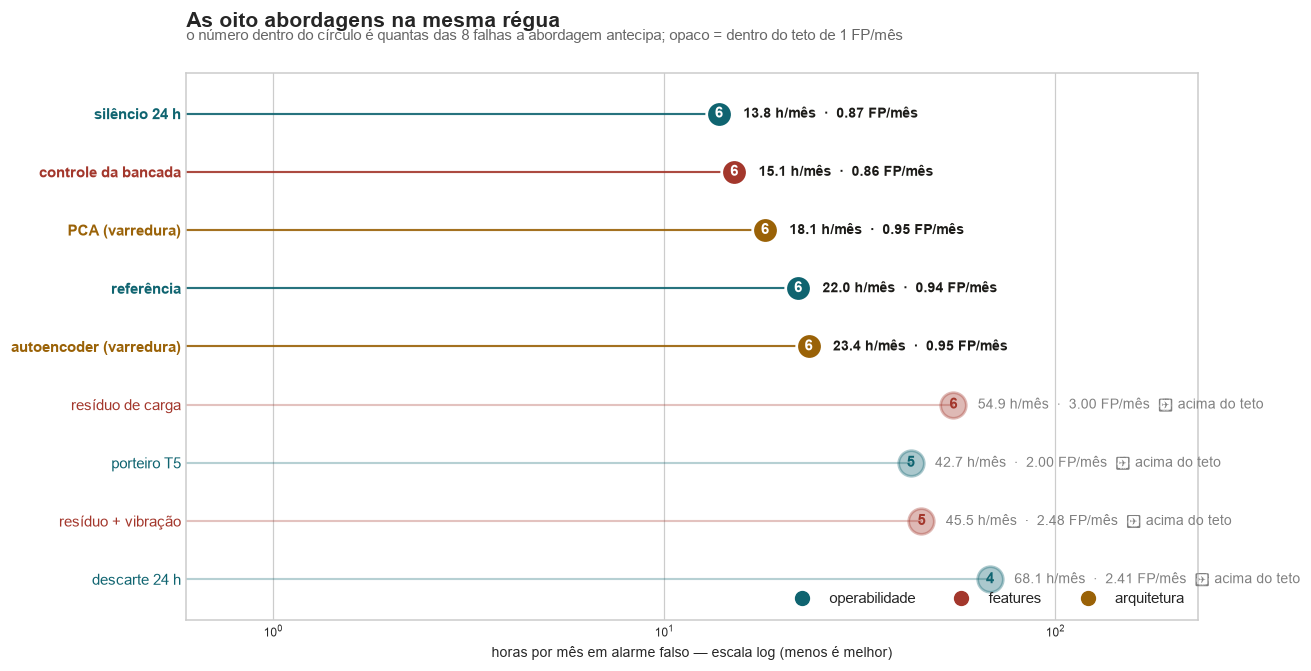

In [7]:
ordem = T.sort_values(["dentro_do_teto", "eventos", "h_alarme_falso"],
                      ascending=[True, True, False])
CORES = {"operabilidade": "#0f6470", "features": "#a3372c", "arquitetura": "#9a6207"}

fig, ax = plt.subplots(figsize=(12, 6.2))
for y, (_, l) in enumerate(ordem.iterrows()):
    dentro = bool(l.dentro_do_teto)
    cor = CORES[l.grupo]
    ax.plot([0.6, l.h_alarme_falso], [y, y], color=cor, lw=1.4,
            alpha=0.9 if dentro else 0.3, zorder=2)
    ax.scatter([l.h_alarme_falso], [y], s=280, color=cor, zorder=4,
               alpha=1.0 if dentro else 0.35,
               edgecolor="white" if dentro else cor, linewidth=1.8)
    ax.text(l.h_alarme_falso, y, f"{int(l.eventos)}", color="white" if dentro else cor,
            ha="center", va="center", fontsize=9.5, fontweight="bold", zorder=5)
    ax.annotate(f"{l.h_alarme_falso:.1f} h/mês  ·  {l.fp_mes:.2f} FP/mês"
                + ("" if dentro else "  ✕ acima do teto"),
                xy=(l.h_alarme_falso, y), xytext=(16, 0), textcoords="offset points",
                va="center", fontsize=9, color="#1c1b18" if dentro else "0.5",
                fontweight="bold" if dentro else "normal")

ax.set_yticks(range(len(ordem)))
ax.set_yticklabels([f"{l.abordagem}" for _, l in ordem.iterrows()], fontsize=10)
for tick, (_, l) in zip(ax.get_yticklabels(), ordem.iterrows()):
    tick.set_color(CORES[l.grupo])
    tick.set_fontweight("bold" if l.dentro_do_teto else "normal")
ax.set_xscale("log")
ax.set_xlim(0.6, ordem.h_alarme_falso.max() * 3.4)
ax.set_xlabel("horas por mês em alarme falso — escala log (menos é melhor)")
ax.set_ylim(-0.7, len(ordem) - 0.3)
ax.grid(axis="y", visible=False)
ax.set_title("As oito abordagens na mesma régua", loc="left", fontweight="bold",
             fontsize=13.5, pad=30)
ax.text(0, 1.06, "o número dentro do círculo é quantas das 8 falhas a abordagem antecipa; "
        "opaco = dentro do teto de 1 FP/mês",
        transform=ax.transAxes, fontsize=9.5, color="0.4")
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([], [], color=c, marker="o", ls="none", ms=9, label=g)
                   for g, c in CORES.items()],
          frameon=False, loc="lower right", fontsize=10, ncol=3)
fig.tight_layout()
destino = RAIZ / "reports/figures/deteccao/comparacao_abordagens.png"
fig.savefig(destino, dpi=150, bbox_inches="tight")
print("figura salva em", destino)
plt.show()

## 5. Veredito

**Vence o silêncio pós-partida de 24 h.** É a única abordagem que melhora alguma coisa sem
piorar outra: mantém as 6 falhas com antecedência idêntica evento a evento e derruba o
tempo em alarme falso de 22,0 para 13,8 h/mês — 37% a menos. Custa 15% do tempo de
operação sem vigilância, e essa é uma troca que a operação precisa aceitar
explicitamente, não nós.

**Empata em segundo o autoencoder**, que entrega as mesmas 6 falhas com antecedência menor
e custo de treino trinta vezes maior. Ele não melhora o detector — mas responde à exigência
de "ter uma técnica de rede neural", e por isso continua na mesa.

**As outras cinco não passam.** O porteiro de exaustão e o descarte de partida caem porque
limpar o baseline desloca o limiar; o resíduo de carga estoura o teto de falso positivo; a
vibração piora nos dois eixos.

**A ressalva que precisa acompanhar o vencedor.** Com o silêncio ligado, as configurações
de 6/8 dentro do teto caem de 7 para 1 — sobra exatamente a que já roda. O resultado passa
a depender de um único ponto do grid, sem alternativa próxima. Antes de adotar 24 h fixos,
vale varrer 12 h e 18 h para achar onde o ganho aparece sem estreitar tanto o espaço. É
uma task de uma hora.

**O que nenhuma delas resolve.** As duas falhas que faltam continuam faltando. A de
04/11/2025 não é antecipada por nenhuma das 10.368 configurações; a de 09/12/2025 só por
configurações a 5,51 FP/mês. O limite ali é de observabilidade dos dados, e a saída é mais
dado — 2024 completo, catálogo validado com a manutenção, vibração com resolução
espectral —, não mais modelo.

## 6. Os resultados finais

Dois estão medidos e um está por vir. A célula abaixo lê `reports/automl/` e preenche
sozinha a linha que faltar, quando o artefato da varredura chegar.

In [8]:

PENDENTES = {"3. filtro de temperatura (T5)": "res_t5gate.parquet",
             "4. T5 + silêncio 24 h": "res_t5_silencio.parquet"}

finais = [
    dict(resultado="1. sem filtro (produção hoje)", eventos="6/8", lead_h=18.3, fp_mes=0.94,
         h_alarme_falso=22.0, dias=350.5, situacao="medido"),
    dict(resultado="2. silêncio pós-partida de 24 h", eventos="6/8", lead_h=18.3, fp_mes=0.87,
         h_alarme_falso=13.8, dias=311.4, situacao="medido"),
]
for rotulo, arquivo in PENDENTES.items():
    caminho = AUTOML / arquivo
    if caminho.exists():
        d = pd.read_parquet(caminho)
        ok = d[d.fp_por_mes <= TETO_FP]
        b = ok.sort_values(["eventos_detectados", "fp_horas_por_mes"],
                           ascending=[False, True]).iloc[0]
        finais.append(dict(resultado=rotulo, eventos=f"{int(b.eventos_detectados)}/8",
                           lead_h=round(float(b.lead_medio_h), 1),
                           fp_mes=round(float(b.fp_por_mes), 2),
                           h_alarme_falso=round(float(b.fp_horas_por_mes), 1),
                           dias=round(float(b.dias_avaliados), 1), situacao="medido"))
    else:
        finais.append(dict(resultado=rotulo, eventos="—", lead_h=None, fp_mes=None,
                           h_alarme_falso=None, dias=None, situacao="varredura pendente"))

display(pd.DataFrame(finais).set_index("resultado"))


,eventos,lead_h,fp_mes,h_alarme_falso,dias,situacao
resultado,,,,,,
1. sem filtro (produção hoje),6/8,18.3,0.94,22.0,350.5,medido
2. silêncio pós-partida de 24 h,6/8,18.3,0.87,13.8,311.4,medido
3. filtro de temperatura (T5),—,NaN,NaN,NaN,NaN,varredura pendente
4. T5 + silêncio 24 h,—,NaN,NaN,NaN,NaN,varredura pendente


**Resultado 1 — sem filtro.** É o que roda hoje: 6 de 8 falhas, 18,3 h de antecedência,
0,94 FP/mês, 22,0 h/mês em alarme falso. É a referência contra a qual tudo se compara.

**Resultado 2 — silêncio pós-partida de 24 h.** Mesmas 6 falhas, mesma antecedência evento
a evento, e o tempo em alarme falso cai para 13,8 h/mês. Custa 15% do tempo de operação
sem vigilância, e reduz de 7 para 1 o número de configurações distintas que entregam 6/8
dentro do teto.

**Resultado 3 — filtro de temperatura (T5), pendente.** O marcador de exaustão
(`T5_AVG_A >= 500 °C`) já está implementado e desligado por padrão. Localmente, em 180
configurações, ele **piora** — 5 de 8 e ~50 h/mês — porque limpar o baseline derruba o
limiar percentil. A varredura completa existe para confirmar ou derrubar esse resultado
com os 10.368 pontos, já que a minha amostra cobre só a vizinhança do ponto atual.

**Resultado 4 — T5 combinado com o silêncio.** Os dois eixos são flags independentes e
podem ser ligados juntos (`--exhaust-gate stable --post-start-silence 24h`). Vale medir
porque o silêncio já é ganho confirmado: a pergunta é se o T5 acrescenta alguma coisa em
cima dele.

```bash
# resultado 3
.venv/bin/python scripts/automl_clearml.py --mode policy_fine --policy-hours 3000 \
  --remote --queue default --task-suffix t5gate-v2 --exhaust-gate stable

# resultado 4
.venv/bin/python scripts/automl_clearml.py --mode policy_fine --policy-hours 3000 \
  --remote --queue default --task-suffix t5-silencio --exhaust-gate stable \
  --post-start-silence 24h
```